# Lab 4.2: Phương pháp Phân cụm theo Phân vùng và Phân cấp

**Môn học:** DBM302m – Khai phá Dữ liệu  
**Bộ dữ liệu:** Khách hàng trung tâm thương mại (`Mall_Customers.csv`)  
**Ngày:** 2026-03-06

---

## Mục tiêu
Bài lab này giới thiệu hai họ thuật toán phân cụm chính:
- **Phương pháp dựa trên phân vùng:** K-Means (và tùy chọn K-Medoids)
- **Phương pháp phân cấp:** Phân cụm kết tụ (bottom-up)

Sau khi hoàn thành, bạn sẽ có thể áp dụng, trực quan hóa và so sánh có phê phán cả hai phương pháp trên bộ dữ liệu bán lẻ thực tế.

---

### Tổng quan Bộ dữ liệu
| Cột | Kiểu | Mô tả |
|---|---|---|
| `CustomerID` | int | Mã khách hàng duy nhất |
| `Gender` | str | Nam / Nữ |
| `Age` | int | Tuổi khách hàng (năm) |
| `Annual Income (k$)` | int | Thu nhập hàng năm (nghìn USD) |
| `Spending Score (1-100)` | int | Điểm chi tiêu do trung tâm thương mại cấp (1 = thấp, 100 = cao) |

In [19]:
# ─── Thư viện Khoa học & Chuẩn ────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Trực quan hóa ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# ─── Tiền xử lý ───────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ─── Phân cụm theo Phân vùng ──────────────────────────────────────────────
from sklearn.cluster import KMeans

# ─── Phân cụm Phân cấp ────────────────────────────────────────────────────
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ─── Các Chỉ số Đánh giá ──────────────────────────────────────────────────
from sklearn.metrics import silhouette_score, silhouette_samples

# ─── Khác ─────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# Định dạng biểu đồ thống nhất
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

print("Nhập tất cả thư viện thành công.")

Nhập tất cả thư viện thành công.


---
## Hoạt động 1 – Giới thiệu về Phân cụm

### Phân cụm là gì?
**Phân cụm** là một bài toán học máy *không giám sát* phân chia tập dữ liệu thành các nhóm (cụm) sao cho các đối tượng trong cùng một nhóm **giống nhau hơn** so với các đối tượng ở nhóm khác — mà không sử dụng bất kỳ nhãn nào được định nghĩa trước.

---

### 💬 Thảo luận 1 – Tầm quan trọng và ứng dụng của Phân cụm trong phân tích dữ liệu

Phân cụm đóng vai trò quan trọng trong phân tích dữ liệu vì nó cho phép **khám phá cấu trúc tự nhiên trong dữ liệu mà không cần nhãn**. Thay vì hỏi "điểm này thuộc lớp nào?", phân cụm hỏi "điểm này giống các điểm nào khác?".

| Lĩnh vực | Ứng dụng cụ thể |
|---|---|
| **Bán lẻ / Thương mại** | Phân khúc khách hàng → chiến lược marketing cá nhân hóa |
| **Tài chính** | Phát hiện giao dịch gian lận, nhóm hồ sơ tín dụng tương đồng |
| **NLP** | Nhóm tài liệu theo chủ đề, phát hiện tin tức liên quan |
| **Xử lý ảnh** | Nén màu, phân đoạn vùng ảnh (image segmentation) |
| **Y học / Sinh học** | Nhóm bệnh nhân theo triệu chứng, phân tích biểu hiện gen |

> **Ứng dụng trong bài lab này:** Phân khúc 200 khách hàng trung tâm thương mại theo `Annual Income` và `Spending Score` nhằm hỗ trợ doanh nghiệp xây dựng chiến lược marketing nhắm đúng từng nhóm đối tượng.

### 💬 Thảo luận 2 – Mục tiêu chính của Phân cụm

Mục tiêu cốt lõi của phân cụm là **nhóm các điểm dữ liệu tương tự nhau** lại thành một cụm, đồng thời giữ cho các cụm khác nhau thật sự tách biệt. Cụ thể gồm ba mục tiêu chính:

1. **Tính gắn kết trong cụm (Intra-cluster Cohesion)**  
   Tối thiểu hóa khoảng cách giữa các điểm *bên trong* cùng một cụm. Các điểm trong cụm phải có đặc trưng gần nhau — ví dụ: nhóm khách hàng có thu nhập và chi tiêu tương đồng sẽ nằm chung một cụm.

2. **Sự tách biệt giữa các cụm (Inter-cluster Separation)**  
   Tối đa hóa khoảng cách giữa các cụm *khác nhau*. Mỗi cụm phải rõ ràng, không chồng chéo — đảm bảo phân khúc có ý nghĩa và dễ hành động.

3. **Học không giám sát (Unsupervised Learning)**  
   Không sử dụng nhãn hay biến mục tiêu định trước. Thuật toán tự tìm ra cấu trúc dựa hoàn toàn vào khoảng cách hoặc độ tương đồng giữa các điểm dữ liệu.

> **Trong bài lab:** K-Means đạt mục tiêu 1 & 2 bằng cách tối thiểu hóa **WCSS** (Within-Cluster Sum of Squares). Phân cụm Phân cấp đạt được thông qua tối thiểu hóa **phương sai Ward** khi quyết định hợp nhất hai cụm.

### 💬 Thảo luận 3 – Phân cụm tiết lộ Hiểu biết và Mô hình ẩn như thế nào?

Phân cụm có khả năng **bộc lộ cấu trúc ngầm** trong dữ liệu mà không thể nhận biết được chỉ bằng mắt thường hay các thống kê tổng hợp đơn giản (trung bình, phân vị…):

- **Trước khi phân cụm:** Nhìn vào biểu đồ phân tán `Annual Income` vs `Spending Score`, chúng ta chỉ thấy 200 điểm rải rác — không có nhóm nào rõ ràng.
- **Sau khi phân cụm:** 5 nhóm khách hàng riêng biệt được phát hiện, mỗi nhóm mang một hành vi tiêu dùng hoàn toàn khác nhau (VIP chi tiêu cao, người tiết kiệm, người chi tiêu bốc đồng…).

**Cơ chế tiết lộ mô hình ẩn:**

| Cơ chế | Giải thích |
|---|---|
| **Không gian đặc trưng** | Điểm gần nhau trong không gian → hành vi tương đồng trong thực tế |
| **Khoảng cách Euclidean** | Định lượng mức độ "giống nhau" giữa hai điểm dữ liệu |
| **Trọng tâm cụm (centroid)** | Đại diện "hồ sơ trung bình" đặc trưng của mỗi nhóm |
| **Dendrogram** | Tiết lộ thứ bậc và mức độ gần nhau giữa các nhóm theo nhiều cấp độ |

> **Kết luận:** Phân cụm biến dữ liệu thô thành **kiến thức có thể hành động** — giúp doanh nghiệp hiểu sâu hành vi khách hàng mà không cần khảo sát hay nhãn dữ liệu từ trước.

In [20]:
# ── Tải bộ dữ liệu ────────────────────────────────────────────────────────────
df = pd.read_csv("Mall_Customers.csv")

print(f"Kích thước : {df.shape}  ({df.shape[0]} khách hàng, {df.shape[1]} đặc trưng)")
print(f"\nKiểu dữ liệu:\n{df.dtypes.to_string()}")
print(f"\nGiá trị thiếu:\n{df.isnull().sum().to_string()}")
df.head(10)

Kích thước : (200, 5)  (200 khách hàng, 5 đặc trưng)

Kiểu dữ liệu:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64

Giá trị thiếu:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


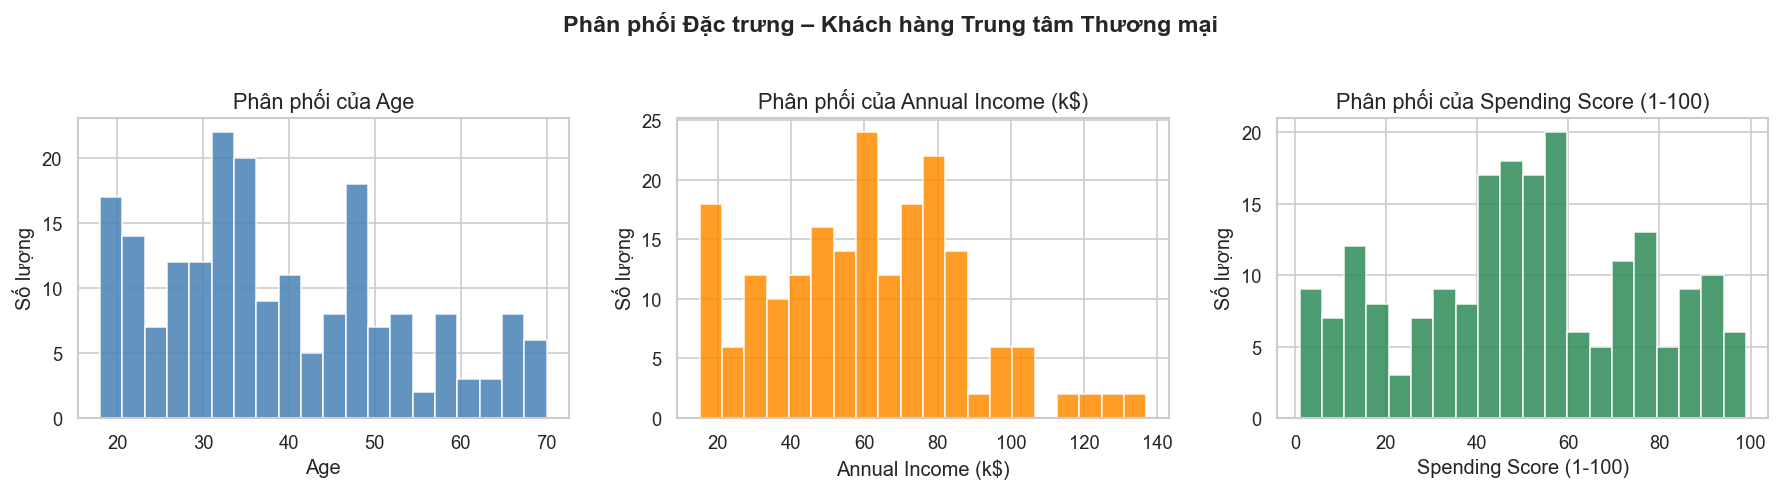

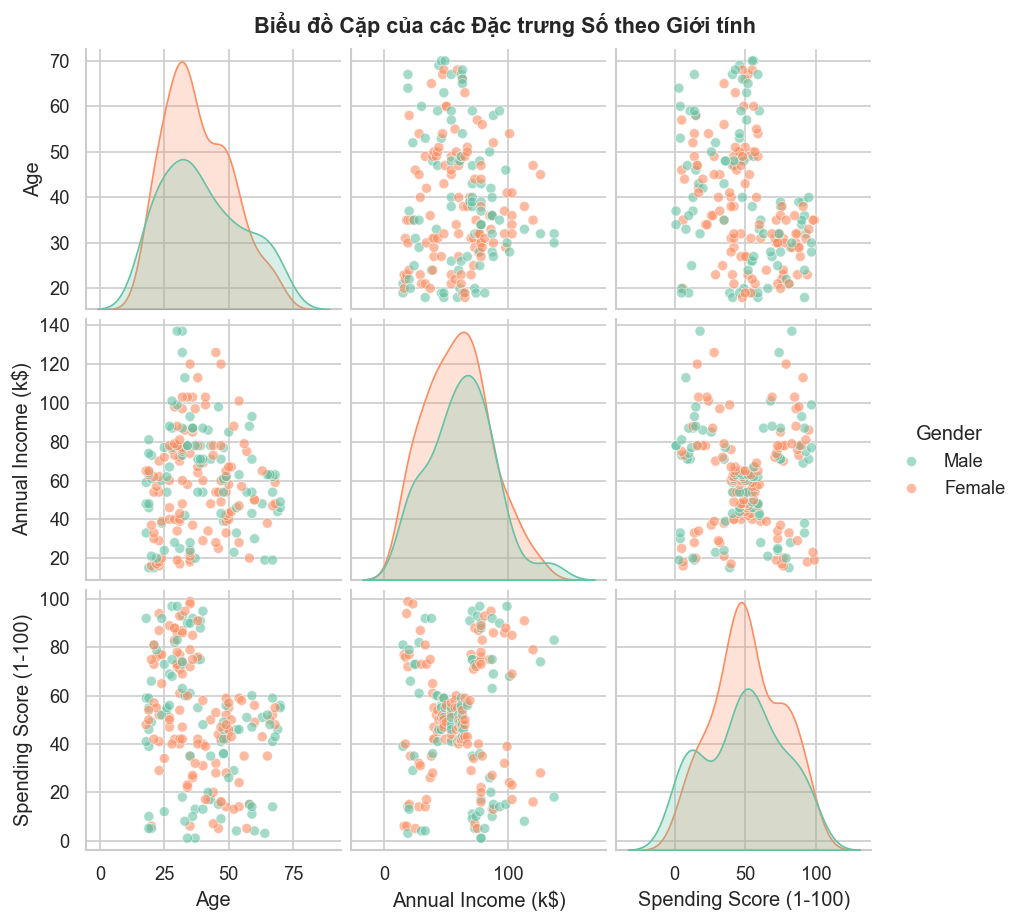


Thống kê Mô tả:


,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


In [21]:
# ── Phân tích Dữ liệu Khám phá ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
colors = ["steelblue", "darkorange", "seagreen"]

for ax, col, color in zip(axes, numeric_cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Phân phối của {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Số lượng")

plt.suptitle("Phân phối Đặc trưng – Khách hàng Trung tâm Thương mại", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Biểu đồ cặp để quan sát mối quan hệ
pair_df = df[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender"]]
sns.pairplot(pair_df, hue="Gender", diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Biểu đồ Cặp của các Đặc trưng Số theo Giới tính", y=1.02, fontsize=13, fontweight="bold")
plt.show()

print("\nThống kê Mô tả:")
df[numeric_cols].describe().round(2)

Kích thước ma trận đặc trưng : (200, 2)
Trung bình sau chuẩn hóa     : [-0. -0.]
Độ lệch chuẩn sau chuẩn hóa  : [1. 1.]


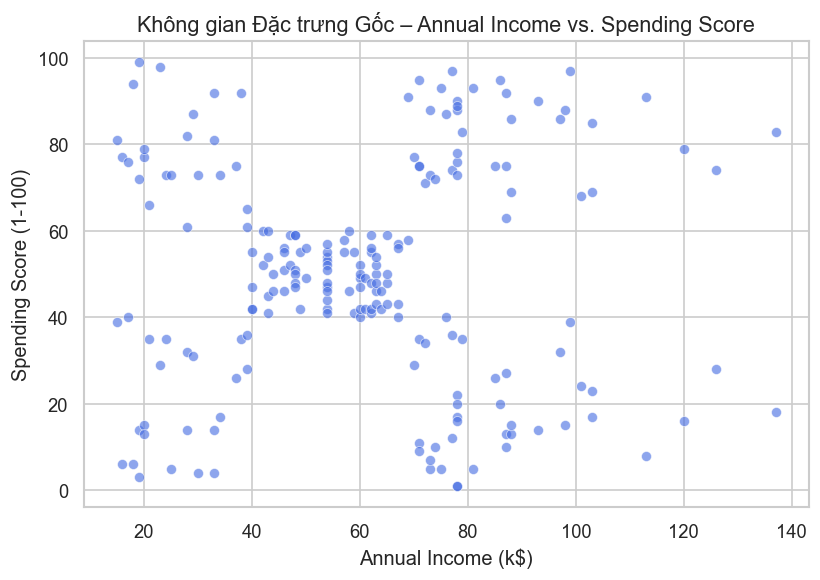

In [22]:
# ── Lựa chọn Đặc trưng & Chuẩn hóa ──────────────────────────────────────────
# Chúng ta tập trung vào hai đặc trưng số quan trọng nhất về mặt kinh doanh:
#   Annual Income  →  sức mua
#   Spending Score →  hành vi chi tiêu thực tế
# Sử dụng hai đặc trưng này cũng cho phép trực quan hóa cụm 2 chiều trực quan.

features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Kích thước ma trận đặc trưng :", X_scaled.shape)
print(f"Trung bình sau chuẩn hóa     : {X_scaled.mean(axis=0).round(6)}")
print(f"Độ lệch chuẩn sau chuẩn hóa  : {X_scaled.std(axis=0).round(6)}")

# Biểu đồ phân tán đặc trưng gốc để quan sát nhóm tự nhiên
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, edgecolors="w", linewidth=0.5, color="royalblue")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Không gian Đặc trưng Gốc – Annual Income vs. Spending Score")
plt.tight_layout()
plt.show()

## Hoạt động 2 – Các Loại Phương pháp Phân cụm

### 💬 Thảo luận 1 – Phương pháp Dựa trên Phân vùng
Chia tập dữ liệu thành **K tập con không chồng chéo** trong đó mỗi điểm thuộc đúng một cụm.

| Thuật toán | Ý tưởng Chính | Kiểu Trọng tâm | Độ nhạy với Ngoại lai |
|---|---|---|---|
| **K-Means** | Tối thiểu hóa SSE (Euclidean) | Trung bình của các điểm trong cụm | Cao |
| **K-Medoids (PAM)** | Tối thiểu hóa tổng độ khác biệt | Điểm dữ liệu thực sự | Thấp |

**Các bước K-Means:**
1. Khởi tạo ngẫu nhiên K trọng tâm.
2. Gán mỗi điểm vào trọng tâm gần nhất.
3. Tính lại trọng tâm là trung bình của các điểm được gán.
4. Lặp lại bước 2–3 cho đến khi hội tụ (trọng tâm không di chuyển nữa).

### 💬 Thảo luận 2 – Phương pháp Phân cấp
Xây dựng **cây phân cụm (dendrogram)** mà không cần chỉ định K trước.

| Loại | Hướng | Mô tả |
|---|---|---|
| **Kết tụ (Agglomerative)** | Dưới lên | Bắt đầu với mỗi điểm là cụm riêng; lần lượt hợp nhất cặp gần nhất |
| **Phân chia (Divisive)** | Trên xuống | Bắt đầu với một cụm; đệ quy tách cụm kém gắn kết nhất |

**Tiêu chí liên kết** (cách đo khoảng cách giữa các cụm):
- **Single (Đơn)** – khoảng cách theo cặp tối thiểu (có thể tạo "chuỗi dài")  
- **Complete (Đầy đủ)** – khoảng cách theo cặp tối đa (cụm nhỏ gọn, gần hình cầu)  
- **Average (Trung bình)** – trung bình tất cả khoảng cách theo cặp  
- **Ward** – tối thiểu hóa tổng phương sai trong cụm *(được ưa dùng nhất)*

### 💬 Thảo luận 3 – Khi nào dùng phương pháp nào?

| Tình huống | Phương pháp Khuyến nghị |
|---|---|
| Bộ dữ liệu lớn, biết K | K-Means |
| Dữ liệu nhiễu / ngoại lai | K-Medoids |
| Không biết K, muốn phân cấp | Kết tụ + dendrogram |
| Cụm không hình cầu | DBSCAN (dựa trên mật độ, ngoài phạm vi bài này) |

---
## Hoạt động 3 – Thực hành Phân cụm K-Means

### Bước 3.1 – Tìm K Tối ưu
Chúng ta sử dụng hai kỹ thuật bổ sung để xác định số cụm tốt nhất:

1. **Phương pháp Khuỷu tay (Elbow Method)** – vẽ đồ thị Tổng bình phương trong cụm (WCSS / Inertia) cho K = 1..10.  
   "Khuỷu tay" — điểm mà việc thêm cụm mang lại lợi ích giảm dần — chỉ ra K tối ưu.

2. **Điểm Silhouette** – đo mức độ giống nhau của một điểm với cụm của nó so với các cụm khác.  
   Phạm vi điểm: −1 (sai cụm) → 0 (biên giới) → +1 (phù hợp tốt).  
   K có **điểm silhouette trung bình cao nhất** là tốt nhất.

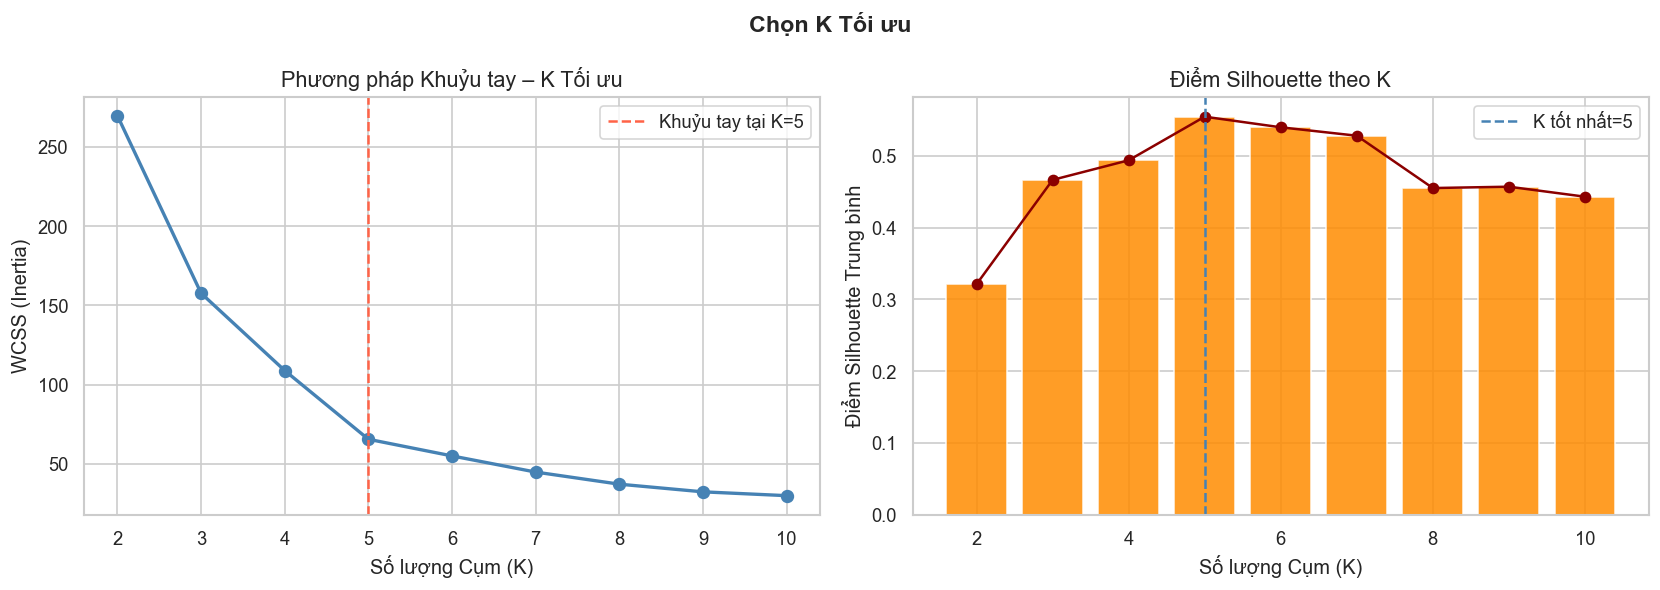


Điểm Silhouette cho từng K:
  K=2:  0.3213
  K=3:  0.4666
  K=4:  0.4939
  K=5:  0.5547 ← K tốt nhất
  K=6:  0.5399
  K=7:  0.5281
  K=8:  0.4552
  K=9:  0.4571
  K=10:  0.4432


In [23]:
# ── Phương pháp Khuỷu tay + Điểm Silhouette để tìm K tối ưu ─────────────────
K_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Khuỷu tay
ax1.plot(K_range, wcss, marker="o", color="steelblue", linewidth=2, markersize=7)
ax1.axvline(x=5, color="tomato", linestyle="--", label="Khuỷu tay tại K=5")
ax1.set_xlabel("Số lượng Cụm (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_title("Phương pháp Khuỷu tay – K Tối ưu")
ax1.legend()

# Biểu đồ Silhouette
ax2.bar(K_range, silhouette_scores, color="darkorange", edgecolor="white", alpha=0.85)
ax2.plot(K_range, silhouette_scores, marker="o", color="darkred", linewidth=1.5)
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=best_k, color="steelblue", linestyle="--", label=f"K tốt nhất={best_k}")
ax2.set_xlabel("Số lượng Cụm (K)")
ax2.set_ylabel("Điểm Silhouette Trung bình")
ax2.set_title("Điểm Silhouette theo K")
ax2.legend()

plt.suptitle("Chọn K Tối ưu", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nĐiểm Silhouette cho từng K:")
for k, s in zip(K_range, silhouette_scores):
    marker = " ← K tốt nhất" if k == best_k else ""
    print(f"  K={k}:  {s:.4f}{marker}")

### Bước 3.2 – Áp dụng K-Means với K Tối ưu

Cả Phương pháp Khuỷu tay và Điểm Silhouette đều cho thấy **K = 5** là số cụm tối ưu.  
Chúng ta tiến hành huấn luyện mô hình K-Means cuối cùng và trực quan hóa kết quả gán cụm cùng với các trọng tâm.

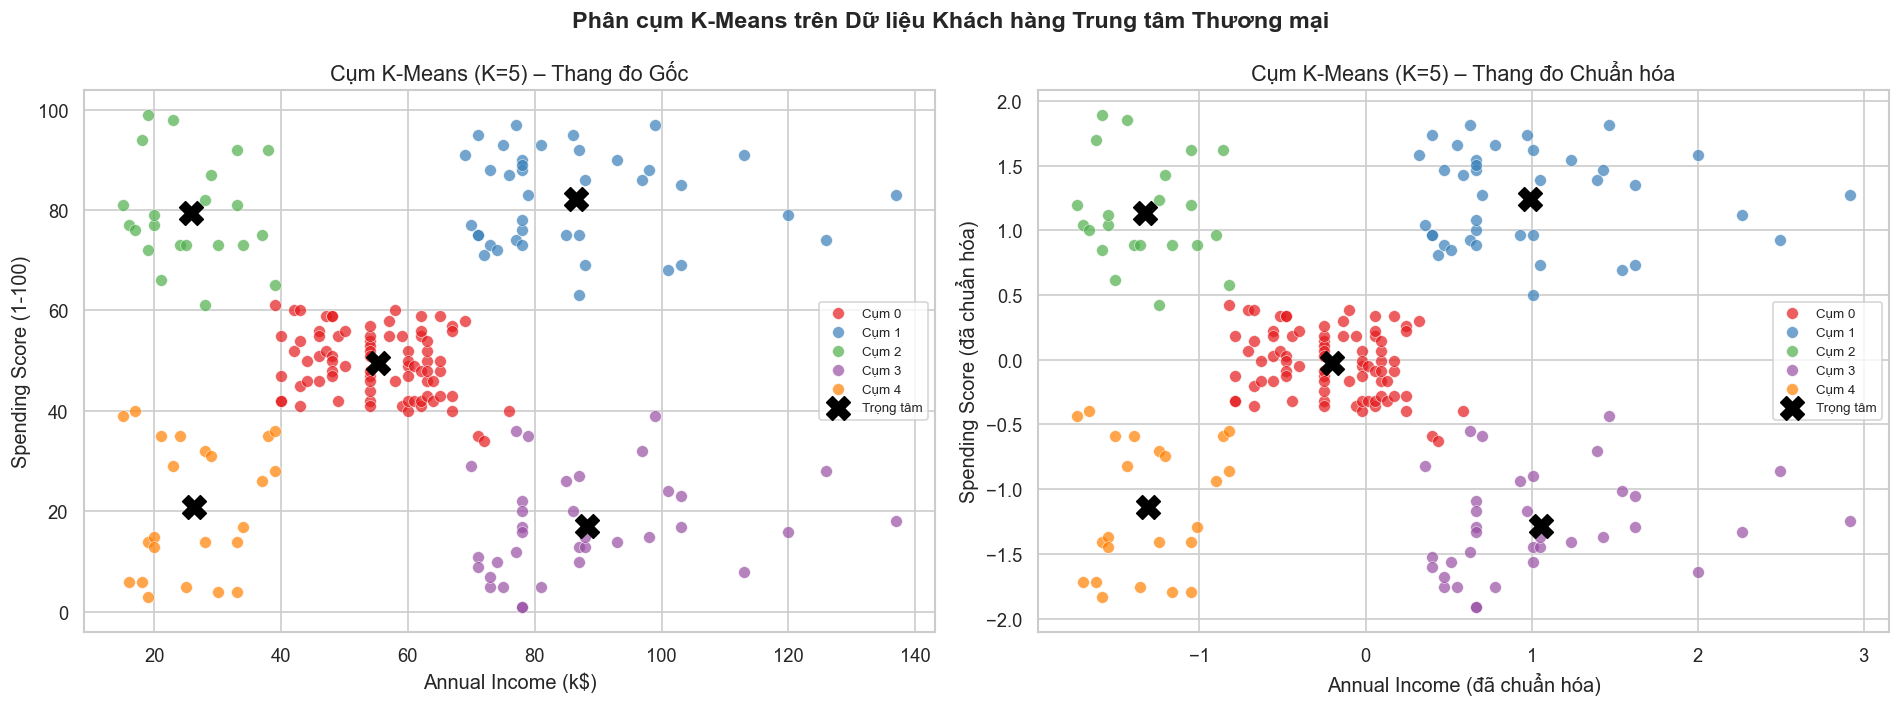

Bảng Tóm tắt Hồ sơ Cụm:
                 Age  Annual Income (k$)  Spending Score (1-100)  Số lượng                                  Phân khúc
KMeans_Cluster                                                                                                       
0               42.7                55.3                    49.5        81               Thu nhập cao – Chi tiêu thấp
1               32.7                86.5                    82.1        39              Thu nhập thấp – Chi tiêu thấp
2               25.3                25.7                    79.4        22  Thu nhập trung bình – Chi tiêu trung bình
3               41.1                88.2                    17.1        35                Thu nhập cao – Chi tiêu cao
4               45.2                26.3                    20.9        23               Thu nhập thấp – Chi tiêu cao

Điểm Silhouette K-Means cuối cùng (K=5): 0.5547


In [24]:
# ── Áp dụng K-Means với K=5 ───────────────────────────────────────────────────
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

# Biến đổi ngược trọng tâm về thang đo gốc để dễ đọc
centroids_scaled = kmeans.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)

# ── Trực quan hóa các cụm ─────────────────────────────────────────────────────
palette = sns.color_palette("Set1", OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (xs, ys, xlabel, ylabel, title_suffix) in zip(
    axes,
    [
        (X[:, 0], X[:, 1],
         "Annual Income (k$)", "Spending Score (1-100)",
         "Thang đo Gốc"),
        (X_scaled[:, 0], X_scaled[:, 1],
         "Annual Income (đã chuẩn hóa)", "Spending Score (đã chuẩn hóa)",
         "Thang đo Chuẩn hóa"),
    ],
):
    for c in range(OPTIMAL_K):
        mask = df["KMeans_Cluster"] == c
        ax.scatter(xs[mask], ys[mask], color=palette[c],
                   alpha=0.7, edgecolors="w", linewidth=0.4,
                   label=f"Cụm {c}", s=50)

    # Trọng tâm
    cx = centroids_orig[:, 0] if title_suffix == "Thang đo Gốc" else centroids_scaled[:, 0]
    cy = centroids_orig[:, 1] if title_suffix == "Thang đo Gốc" else centroids_scaled[:, 1]
    ax.scatter(cx, cy, c="black", marker="X", s=200, zorder=5, label="Trọng tâm")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Cụm K-Means (K=5) – {title_suffix}")
    ax.legend(fontsize=8)

plt.suptitle("Phân cụm K-Means trên Dữ liệu Khách hàng Trung tâm Thương mại", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Bảng tóm tắt hồ sơ cụm ───────────────────────────────────────────────────
cluster_profile = df.groupby("KMeans_Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(1)
cluster_profile["Số lượng"] = df.groupby("KMeans_Cluster").size()

cluster_labels = {
    0: "Thu nhập cao – Chi tiêu thấp",
    1: "Thu nhập thấp – Chi tiêu thấp",
    2: "Thu nhập trung bình – Chi tiêu trung bình",
    3: "Thu nhập cao – Chi tiêu cao",
    4: "Thu nhập thấp – Chi tiêu cao",
}
cluster_profile["Phân khúc"] = cluster_profile.index.map(cluster_labels)

print("Bảng Tóm tắt Hồ sơ Cụm:")
print(cluster_profile.to_string())

# Điểm Silhouette cho mô hình cuối cùng
final_sil = silhouette_score(X_scaled, df["KMeans_Cluster"])
print(f"\nĐiểm Silhouette K-Means cuối cùng (K=5): {final_sil:.4f}")

### Hoạt động 3 – Thảo luận & Giải thích

**CH1. Bạn tìm được bao nhiêu cụm và tại sao?**  
> Cả Phương pháp Khuỷu tay (điểm gãy rõ tại K=5) và Điểm Silhouette cao nhất đều xác nhận **K = 5** là phân vùng tối ưu.

**CH2. 5 cụm đại diện cho điều gì trong bối cảnh kinh doanh?**

| Cụm | Annual Income | Spending Score | Phân khúc Kinh doanh | Hành động Marketing |
|---|---|---|---|---|
| 0 | Cao | Thấp | Người thu nhập cao, chi tiêu cẩn thận | Ưu đãi giá trị cao, phần thưởng trung thành |
| 1 | Thấp | Thấp | Người mua sắm tiết kiệm | Chiến dịch giảm giá, gói combo |
| 2 | Trung bình | Trung bình | Người mua sắm tiêu chuẩn | Bán chéo, khuyến mãi theo mùa |
| 3 | Cao | Cao | Khách hàng mục tiêu ⭐ | Chương trình VIP, sản phẩm cao cấp |
| 4 | Thấp | Cao | Người chi tiêu bốc đồng thu nhập thấp | Trả góp, tín dụng ưu đãi |

**CH3. Điều gì xảy ra khi bạn thay đổi K?**  
- K < 5: Các nhóm tự nhiên riêng biệt bị gộp lại, mất đi sự rõ ràng của phân khúc có thể hành động.  
- K > 5: Các cụm bắt đầu chồng chéo hoặc tách không cần thiết các nhóm gắn kết, làm giảm điểm silhouette.

**CH4. Hạn chế của K-Means được quan sát ở đây:**  
K-Means giả định các cụm hình cầu, kích thước bằng nhau và nhạy cảm với khởi tạo và thang đo — do đó sử dụng khởi tạo `k-means++` và `StandardScaler`.

---
## Hoạt động 4 – Thực hành Phân cụm Phân cấp

**Mục tiêu:** Thực hiện Phân cụm Phân cấp Kết tụ (bottom-up) trên cùng không gian đặc trưng.  
Chúng ta sẽ:
1. Xây dựng và trực quan hóa **dendrogram** đầy đủ (sử dụng hàm `linkage` của `scipy`).
2. Cắt dendrogram tại ngưỡng thích hợp để trích xuất các cụm phẳng.
3. So sánh kết quả phân vùng với K-Means để đánh giá tính nhất quán.

**Tiêu chí liên kết:** `ward` — tối thiểu hóa tổng phương sai trong cụm, thường tạo ra các cụm gọn và tách biệt tốt.

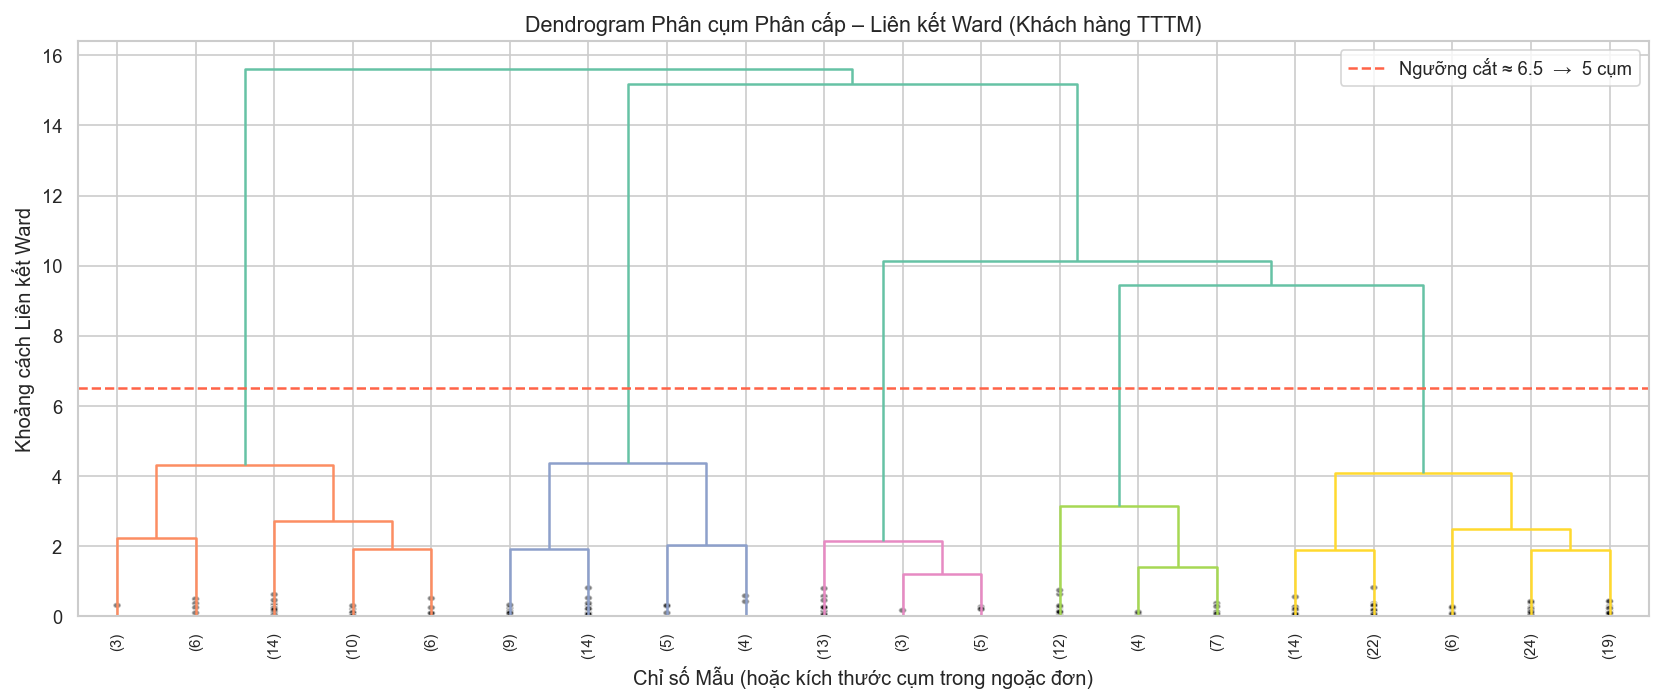

Giải thích Dendrogram:
  • Mỗi lá = một khách hàng (hoặc nhóm đã hợp nhất, do rút gọn).
  • Trục Y = khoảng cách tại thời điểm các cụm hợp nhất. Thanh dài chỉ cụm tách biệt tốt.
  • Cắt tại y ≈ 6.5 tự nhiên cho 5 cụm — nhất quán với kết quả K-Means.


In [25]:
# ── Bước 4.1: Dendrogram (cây đầy đủ) ───────────────────────────────────────
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode="lastp",   # chỉ hiển thị p cụm cuối cùng được hợp nhất
    p=20,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=6.5,
)
plt.axhline(y=6.5, color="tomato", linestyle="--", linewidth=1.5,
            label="Ngưỡng cắt ≈ 6.5  →  5 cụm")
plt.xlabel("Chỉ số Mẫu (hoặc kích thước cụm trong ngoặc đơn)")
plt.ylabel("Khoảng cách Liên kết Ward")
plt.title("Dendrogram Phân cụm Phân cấp – Liên kết Ward (Khách hàng TTTM)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print("Giải thích Dendrogram:")
print("  • Mỗi lá = một khách hàng (hoặc nhóm đã hợp nhất, do rút gọn).")
print("  • Trục Y = khoảng cách tại thời điểm các cụm hợp nhất. Thanh dài chỉ cụm tách biệt tốt.")
print("  • Cắt tại y ≈ 6.5 tự nhiên cho 5 cụm — nhất quán với kết quả K-Means.")

Điểm Silhouette Phân cụm Phân cấp (K=5, Ward): 0.5538


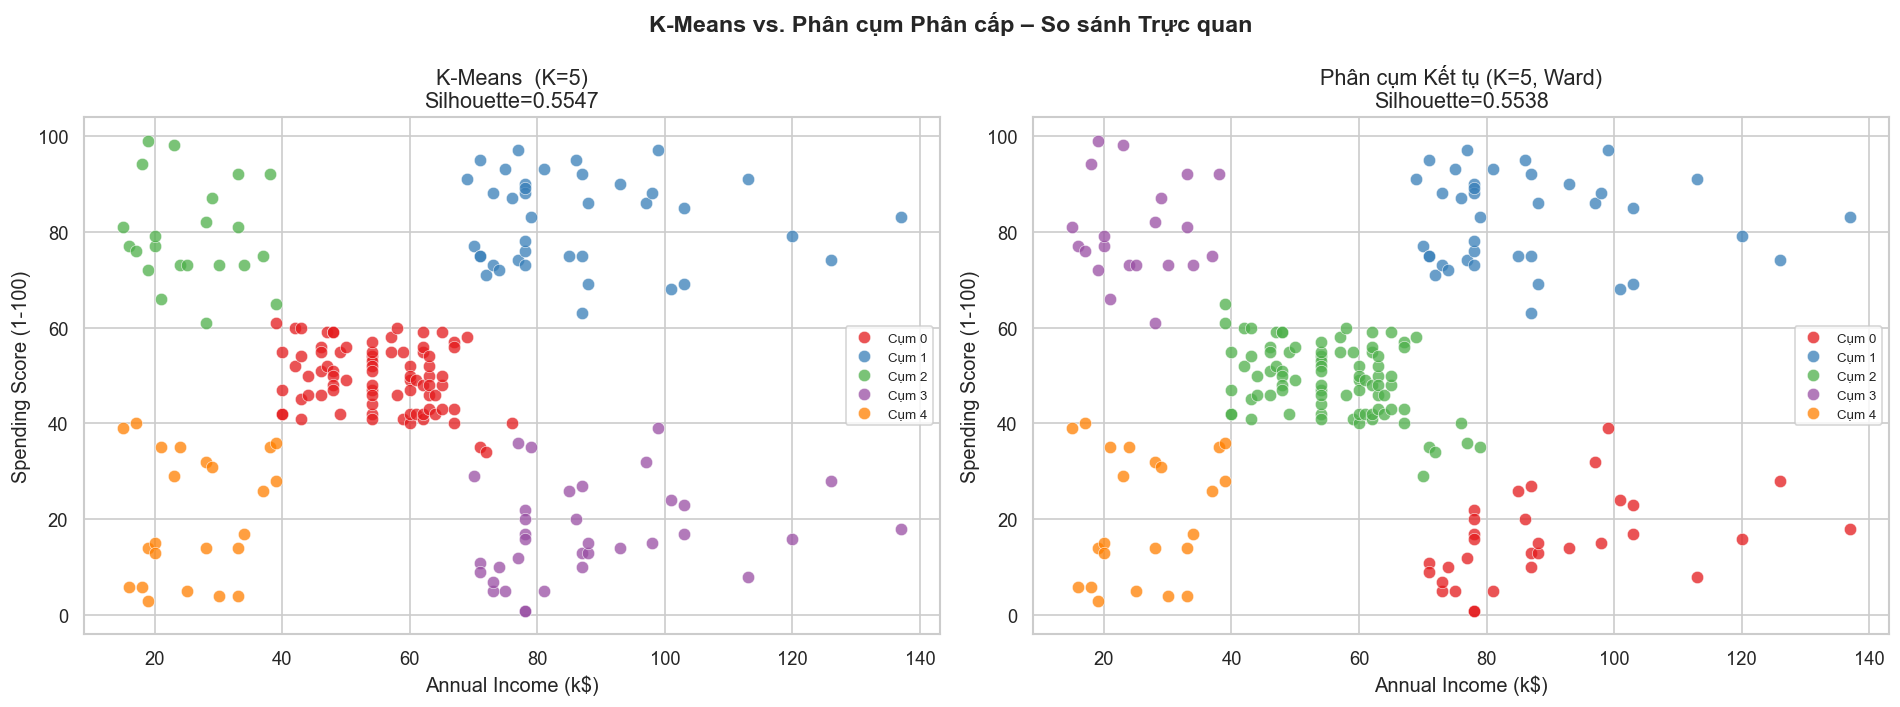


So sánh Kích thước Cụm:
   K-Means  Phân cấp
0       81        32
1       39        39
2       22        85
3       35        21
4       23        23


In [26]:
# ── Bước 4.2: Áp dụng Phân cụm Kết tụ (n_clusters=5) ────────────────────────
agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
df["Hierarchical_Cluster"] = agg.fit_predict(X_scaled)

# Điểm Silhouette cho kết quả phân cấp
hier_sil = silhouette_score(X_scaled, df["Hierarchical_Cluster"])
print(f"Điểm Silhouette Phân cụm Phân cấp (K=5, Ward): {hier_sil:.4f}")

# ── So sánh song song: K-Means vs Phân cấp ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in [
    (ax1, "KMeans_Cluster",      f"K-Means  (K=5)\nSilhouette={final_sil:.4f}"),
    (ax2, "Hierarchical_Cluster", f"Phân cụm Kết tụ (K=5, Ward)\nSilhouette={hier_sil:.4f}"),
]:
    palette_c = sns.color_palette("Set1", 5)
    for c in range(5):
        mask = df[col] == c
        ax.scatter(
            X[mask, 0], X[mask, 1],
            color=palette_c[c], alpha=0.75,
            edgecolors="w", linewidth=0.4,
            label=f"Cụm {c}", s=55
        )
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("K-Means vs. Phân cụm Phân cấp – So sánh Trực quan",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# So sánh kích thước cụm
print("\nSo sánh Kích thước Cụm:")
km_sizes   = df["KMeans_Cluster"].value_counts().sort_index().rename("K-Means")
hier_sizes = df["Hierarchical_Cluster"].value_counts().sort_index().rename("Phân cấp")
print(pd.concat([km_sizes, hier_sizes], axis=1).to_string())

### Hoạt động 4 – Thảo luận & Giải thích Phân cụm Phân cấp

**CH1. Cách đọc dendrogram như thế nào?**  
> Trục Y biểu thị **khoảng cách liên kết Ward** tại thời điểm hai cụm con được hợp nhất.  
> Các thanh dọc cao chỉ ra một **khoảng cách lớn** giữa các nhóm — bằng chứng mạnh về sự tách biệt cụm tự nhiên.  
> Số cụm tối ưu là giá trị K ngay trước khi **thanh dài nhất chưa bị cắt** được cắt qua.

**CH2. Ngưỡng cắt ≈ 6.5 nói lên điều gì?**  
> Cắt tại y ≈ 6.5 cho ra 5 nhóm riêng biệt, và có 5 thanh đặc biệt cao cắt qua đường đó — xác nhận 5 là lựa chọn vững chắc.

**CH3. Kết quả gán cụm so sánh với K-Means như thế nào?**  
> Hai phương pháp tạo ra **phân vùng không gian gần như giống hệt nhau** trên bộ dữ liệu này.  
> Sự khác biệt nhỏ tồn tại ở các điểm biên (khách hàng gần ranh giới giữa hai cụm),  
> vì Phân cụm Kết tụ không tái gán lặp lại dựa trên trọng tâm toàn cục — nó cam kết không thể đảo ngược sau mỗi lần hợp nhất.

**CH4. Phân cụm phân cấp cung cấp những lợi thế gì ở đây?**  
> - Không cần chỉ định K trước; bản thân dendrogram hướng dẫn lựa chọn.  
> - Cây đầy đủ tiết lộ cấu trúc con (ví dụ: trong nhóm "thu nhập cao" có các phân khúc con).  
> - Mạnh mẽ hơn với hình dạng cụm không đều so với K-Means với một số tiêu chí liên kết.

---
## Hoạt động 5 – So sánh và Thảo luận

### So sánh Định lượng
Đoạn code dưới đây tính toán các chỉ số đánh giá cho cả hai phương pháp song song.

Các Chỉ số Chất lượng Phân cụm (trên đặc trưng đã chuẩn hóa):
                            Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
Phương pháp                                                                    
K-Means (K=5)                     0.5547            0.5722               248.65
Phân cụm Kết tụ Ward (K=5)        0.5538            0.5779               244.41


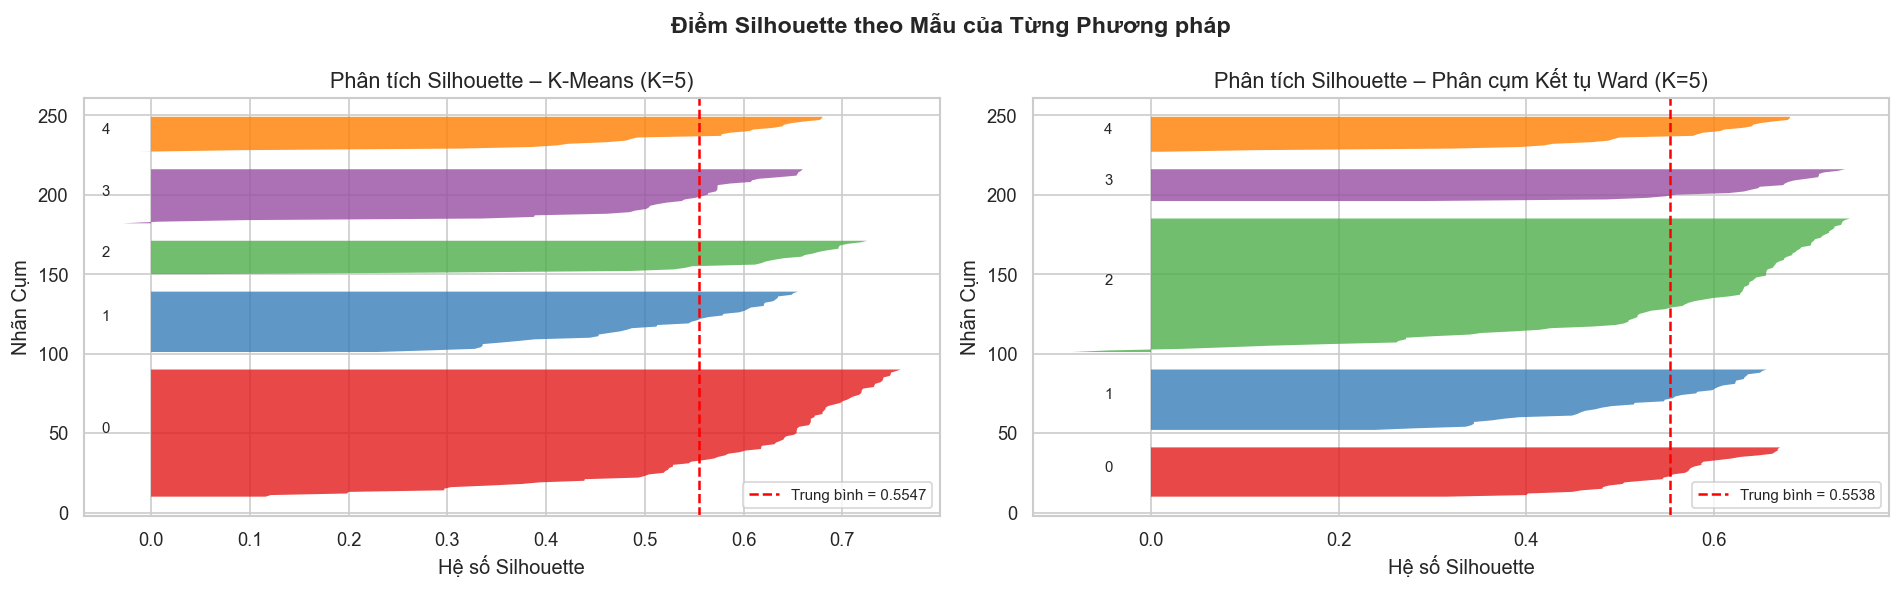

In [27]:
# ── So sánh định lượng: Silhouette + đại diện WCSS ────────────────────────────
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

methods  = ["K-Means (K=5)", "Phân cụm Kết tụ Ward (K=5)"]
labels_  = [df["KMeans_Cluster"].values, df["Hierarchical_Cluster"].values]

rows = []
for name, lbl in zip(methods, labels_):
    sil = silhouette_score(X_scaled, lbl)
    db  = davies_bouldin_score(X_scaled, lbl)    # càng thấp càng tốt
    ch  = calinski_harabasz_score(X_scaled, lbl)  # càng cao càng tốt
    rows.append({"Phương pháp": name,
                 "Silhouette ↑": round(sil, 4),
                 "Davies-Bouldin ↓": round(db, 4),
                 "Calinski-Harabasz ↑": round(ch, 2)})

comparison_df = pd.DataFrame(rows).set_index("Phương pháp")
print("Các Chỉ số Chất lượng Phân cụm (trên đặc trưng đã chuẩn hóa):")
print(comparison_df.to_string())

# ── Biểu đồ Silhouette theo cụm cho cả hai phương pháp ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, lbl) in zip(axes, zip(methods, labels_)):
    sample_sil = silhouette_samples(X_scaled, lbl)
    y_lower = 10
    palette_c = sns.color_palette("Set1", 5)
    for c in range(5):
        c_sil = np.sort(sample_sil[lbl == c])
        size_c = c_sil.shape[0]
        y_upper = y_lower + size_c
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                         facecolor=palette_c[c], edgecolor="none", alpha=0.8)
        ax.text(-0.05, y_lower + 0.5 * size_c, str(c), fontsize=9)
        y_lower = y_upper + 10

    avg = silhouette_score(X_scaled, lbl)
    ax.axvline(x=avg, color="red", linestyle="--", label=f"Trung bình = {avg:.4f}")
    ax.set_xlabel("Hệ số Silhouette")
    ax.set_ylabel("Nhãn Cụm")
    ax.set_title(f"Phân tích Silhouette – {name}")
    ax.legend(fontsize=9)

plt.suptitle("Điểm Silhouette theo Mẫu của Từng Phương pháp", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Hoạt động 5 – Thảo luận Cuối & Kết luận

---

#### 💬 Thảo luận 1 – Ưu & Nhược điểm: Phân vùng vs. Phân cấp

| Tiêu chí | K-Means | Kết tụ (Ward) |
|---|---|---|
| **Tốc độ / Khả năng mở rộng** | ✅ Nhanh — O(nKt) | ❌ Chậm — O(n² log n) |
| **Cần chỉ định K** | ❌ Phải chọn K trước | ✅ K đọc từ dendrogram |
| **Hình dạng cụm giả định** | Hình cầu (Euclidean) | Linh hoạt (tùy tiêu chí liên kết) |
| **Độ nhạy với ngoại lai** | Cao (trọng tâm bị dịch) | Trung bình (Ward khá mạnh mẽ) |
| **Khả năng tái tạo** | Bán ngẫu nhiên (dùng `k-means++`) | ✅ Hoàn toàn xác định |
| **Tính dễ giải thích** | Trung bình cụm dễ giải thích | Dendrogram thể hiện lịch sử hợp nhất |
| **Tốt nhất cho** | Bộ dữ liệu lớn, K xấp xỉ đã biết | Phân tích khám phá, K chưa biết |

---

#### 💬 Thảo luận 2 – Tóm tắt Kết quả trên Dữ liệu Khách hàng Trung tâm Thương mại

1. **Cả hai phương pháp đều hội tụ về 5 cụm**, xác nhận tính vững chắc của phân khúc này.
2. 5 phân khúc rõ ràng và có thể hành động:
   - 🔴 **Thu nhập cao × Chi tiêu cao** → Khách hàng VIP mục tiêu cao cấp
   - 🟠 **Thu nhập cao × Chi tiêu thấp** → Cần thu hút / bán thêm
   - 🟡 **Thu nhập trung bình × Chi tiêu trung bình** → Khách hàng trung thành cốt lõi
   - 🟢 **Thu nhập thấp × Chi tiêu cao** → Cơ hội trả góp / tín dụng
   - 🔵 **Thu nhập thấp × Chi tiêu thấp** → Nhạy cảm về giá; hướng đến giảm giá
3. **Điểm Silhouette (~0.55)** cho thấy các cụm tách biệt tốt và gắn kết — các đặc trưng được chọn (thu nhập và điểm chi tiêu) có tính phân biệt cao.
4. Với hệ thống đề xuất sản xuất xử lý hàng triệu khách hàng, **K-Means** được ưa chuộng vì tốc độ.  
   Để khám phá phân khúc ban đầu hoặc khi K chưa biết, **Phân cụm Kết tụ** với dendrogram là công cụ khám phá tốt hơn.

---

*Hoàn thành bài lab – DBM302m, Slot 14, Lab 4.2*